In [1]:
!ros2

usage: ros2 [-h] [--use-python-default-buffering]
            Call `ros2 <command> -h` for more detailed usage. ...

ros2 is an extensible command-line tool for ROS 2.

options:
  -h, --help            show this help message and exit
  --use-python-default-buffering
                        Do not force line buffering in stdout and instead use
                        the python default buffering, which might be affected
                        by PYTHONUNBUFFERED/-u and depends on whatever stdout
                        is interactive or not

Commands:
  action     Various action related sub-commands
  bag        Various rosbag related sub-commands
  component  Various component related sub-commands
  daemon     Various daemon related sub-commands
  doctor     Check ROS setup and other potential issues
  interface  Show information about ROS interfaces
  launch     Run a launch file
  lifecycle  Various lifecycle related sub-commands
  multicast  Various multicast related sub-commands
 

In [17]:
import os
import pickle
import numpy as np
import torch
from tqdm import tqdm
from openai import OpenAI
import base64
import io
from PIL import Image
from typing import Any
import time
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import asdict, dataclass, field

In [8]:
#Lerobot
from lerobot.datasets.dataset_tools import modify_features
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.utils import dataset_to_policy_features
from lerobot.VLA.lerobot_dataset_LLMVLA import LeRobotDataset_LLMVLA
from lerobot.policies.groot.modeling_groot import GrootPolicy
from lerobot.configs.policies import PreTrainedConfig
from lerobot.policies.factory import make_policy, make_pre_post_processors
from lerobot.processor.rename_processor import rename_stats
from lerobot.datasets.utils import build_dataset_frame, combine_feature_dicts
from lerobot.utils.constants import ACTION, OBS_STR
from lerobot.processor import make_default_processors
from lerobot.utils.control_utils import predict_action
from lerobot.utils.utils import get_safe_torch_device
from lerobot.utils.control_utils import predict_action
from lerobot.utils.utils import get_safe_torch_device
from lerobot.processor import RobotAction

In [9]:
#ROS2
from lerobot.Isaac_sim.ROS_Video import spin_once, JointReader, ros_to_lerobot, lerobot_to_ros, ArmPublisher, ImageSubscriber
import rclpy
from rclpy.node import Node

In [18]:
@dataclass
class DatasetRecordConfig:
    # Dataset identifier. By convention it should match '{hf_username}/{dataset_name}' (e.g. `lerobot/test`).
    repo_id: str
    # A short but accurate description of the task performed during the recording (e.g. "Pick the Lego block and drop it in the box on the right.")
    single_task: str
    # Root directory where the dataset will be stored (e.g. 'dataset/path').
    root: str | Path | None = None
    # Limit the frames per second.
    fps: int = 30
    # Number of seconds for data recording for each episode.
    episode_time_s: int | float = 60
    # Number of seconds for resetting the environment after each episode.
    reset_time_s: int | float = 60
    # Number of episodes to record.
    num_episodes: int = 50
    # Encode frames in the dataset into video
    video: bool = True
    # Upload dataset to Hugging Face hub.
    push_to_hub: bool = True
    # Upload on private repository on the Hugging Face hub.
    private: bool = False
    # Add tags to your dataset on the hub.
    tags: list[str] | None = None
    # Number of subprocesses handling the saving of frames as PNG. Set to 0 to use threads only;
    # set to ≥1 to use subprocesses, each using threads to write images. The best number of processes
    # and threads depends on your system. We recommend 4 threads per camera with 0 processes.
    # If fps is unstable, adjust the thread count. If still unstable, try using 1 or more subprocesses.
    num_image_writer_processes: int = 0
    # Number of threads writing the frames as png images on disk, per camera.
    # Too many threads might cause unstable teleoperation fps due to main thread being blocked.
    # Not enough threads might cause low camera fps.
    num_image_writer_threads_per_camera: int = 4
    # Number of episodes to record before batch encoding videos
    # Set to 1 for immediate encoding (default behavior), or higher for batched encoding
    video_encoding_batch_size: int = 1
    # Rename map for the observation to override the image and state keys
    rename_map: dict[str, str] = field(default_factory=dict)

    def __post_init__(self):
        if self.single_task is None:
            raise ValueError("You need to provide a task as argument in `single_task`.")

In [20]:
client = OpenAI(
    base_url="https://api.tokenfactory.nebius.com/v1/",
    api_key="v1.CmQKHHN0YXRpY2tleS1lMDBibWU2MGZkcnhmNnMxcHQSIXNlcnZpY2VhY2NvdW50LWUwMHNuODBqdDh5aDZkMmZmMzIMCJbI3M0GELis5KQDOgwIlcv0mAcQgMmZrANAAloDZTAw.AAAAAAAAAAHXaOqI8q_cswDId2YWDpmf-iVeOPtlcCiuUj9PTgm585w5iOxd2LCNnLYXVFAR-RatJYYvvHuBHolTpHQ5DgYB",
)

In [10]:
dataset = LeRobotDataset("zhoumiaosen/Isaac_Sim_Put_Cube_To_Basket_LLM")
repo_id = "zhoumiaosen/Isaac_Sim_Put_Cube_To_Basket_Base"
cfg = PreTrainedConfig.from_pretrained(repo_id)
cfg

GrootConfig(n_obs_steps=1, input_features={'observation.state': PolicyFeature(type=<FeatureType.STATE: 'STATE'>, shape=(6,)), 'observation.images.top': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 720, 1280)), 'observation.images.left': PolicyFeature(type=<FeatureType.VISUAL: 'VISUAL'>, shape=(3, 720, 1280))}, output_features={'action': PolicyFeature(type=<FeatureType.ACTION: 'ACTION'>, shape=(6,))}, device='cuda', use_amp=False, push_to_hub=True, repo_id='zhoumiaosen/Isaac_Sim_Put_Cube_To_Basket_Base', private=None, tags=None, license=None, pretrained_path=None, chunk_size=50, n_action_steps=50, max_state_dim=64, max_action_dim=32, normalization_mapping={'VISUAL': <NormalizationMode.IDENTITY: 'IDENTITY'>, 'STATE': <NormalizationMode.MEAN_STD: 'MEAN_STD'>, 'ACTION': <NormalizationMode.MEAN_STD: 'MEAN_STD'>}, image_size=(224, 224), base_model_path='nvidia/GR00T-N1.5-3B', tokenizer_assets_repo='lerobot/eagle2hg-processor-groot-n1p5', embodiment_tag='new_embodiment', tune_

In [13]:
policy_path = "/home/student2/miaosen/Models/Isaac/long/40K"  
repo_id = "zhoumiaosen/Isaac_Sim_Put_Cube_To_Basket_LLM_Qwen"
cfg = PreTrainedConfig.from_pretrained(repo_id)
cfg.pretrained_path=policy_path
policy = make_policy(cfg, ds_meta=dataset.meta)

[GROOT] Flash Attention version: 2.8.3
Loading pretrained dual brain from nvidia/GR00T-N1.5-3B
Tune backbone vision tower: False
Tune backbone LLM: False
Tune action head projector: True
Tune action head DiT: False


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

GR00TN15 has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


[GROOT] Copying vendor Eagle files to cache: /home/student2/miaosen/workspace/lerobot/src/lerobot/policies/groot/eagle2_hg_model -> /home/student2/.cache/huggingface/lerobot/lerobot/eagle2hg-processor-groot-n1p5
[GROOT] Assets repo: lerobot/eagle2hg-processor-groot-n1p5 
 Cache dir: /home/student2/.cache/huggingface/lerobot/lerobot/eagle2hg-processor-groot-n1p5
Tune backbone llm: False
Tune backbone visual: True
Total number of DiT parameters:  550386688
Total number of SelfAttentionTransformer parameters:  201433088
Tune action head projector: True
Tune action head diffusion model: True


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

GR00TN15 has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.
GR00TN15 has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwar

Tune backbone llm: False
Tune backbone visual: False
Tune action head projector: True
Tune action head diffusion model: False
Loading weights from local directory


In [14]:
policy.eval()

GrootPolicy(
  (_groot_model): GR00TN15(
    (backbone): EagleBackbone(
      (eagle_model): Eagle25VLForConditionalGeneration(
        (vision_model): SiglipVisionModel(
          (vision_model): SiglipVisionTransformer(
            (embeddings): SiglipVisionEmbeddings(
              (patch_embedding): Conv2d(3, 1152, kernel_size=(14, 14), stride=(14, 14), padding=valid)
              (position_embedding): Embedding(256, 1152)
            )
            (encoder): SiglipEncoder(
              (layers): ModuleList(
                (0-26): 27 x SiglipEncoderLayer(
                  (layer_norm1): LayerNorm((1152,), eps=1e-06, elementwise_affine=True)
                  (self_attn): SiglipAttention(
                    (k_proj): Linear(in_features=1152, out_features=1152, bias=True)
                    (v_proj): Linear(in_features=1152, out_features=1152, bias=True)
                    (q_proj): Linear(in_features=1152, out_features=1152, bias=True)
                    (out_proj): Linear(i

In [16]:
teleop_action_processor, robot_action_processor, robot_observation_processor = make_default_processors()

In [19]:
dataset_cfg = DatasetRecordConfig(repo_id="zhoumiaosen/Isaac_Sim_Put_Cube_To_Basket_LLM", single_task="put cube to basket")
preprocessor = None
postprocessor = None
preprocessor, postprocessor = make_pre_post_processors(
            policy_cfg=cfg,
            pretrained_path=cfg.pretrained_path,
            dataset_stats=rename_stats(dataset.meta.stats, dataset_cfg.rename_map),
            preprocessor_overrides={
                "device_processor": {"device": cfg.device},
                "rename_observations_processor": {"rename_map": dataset_cfg.rename_map},
            },
        )

In [21]:
obs = {
    'shoulder_pan.pos': 47.36842105263156,
    'shoulder_lift.pos': -98.24132877381534,
    'elbow_flex.pos': 100.0,
    'wrist_flex.pos': 59.79235488437942,
    'wrist_roll.pos': -6.813186813186817,
    'gripper.pos': 2.917981072555205
}

# Get the tensors from the dataset (assuming PyTorch)
top_tensor = dataset[10]['observation.images.top']   # shape: [3, 720, 1280] (CHW)
left_tensor = dataset[10]['observation.images.left']

# --- Process top image ---
top_img = top_tensor.detach().cpu()          # ensure CPU, no gradient
top_img = top_img.permute(1, 2, 0)           # CHW → HWC
top_np = top_img.numpy()
if top_np.max() <= 1.0:
    top_np = (top_np * 255).astype(np.uint8)
else:
    top_np = top_np.astype(np.uint8)         # already in 0‑255

# --- Process left image ---
left_img = left_tensor.detach().cpu()
left_img = left_img.permute(1, 2, 0)
left_np = left_img.numpy()
if left_np.max() <= 1.0:
    left_np = (left_np * 255).astype(np.uint8)
else:
    left_np = left_np.astype(np.uint8)

# --- Build observation dict ---
obs = {
    'shoulder_pan.pos': 47.36842105263156,
    'shoulder_lift.pos': -98.24132877381534,
    'elbow_flex.pos': 100.0,
    'wrist_flex.pos': 59.79235488437942,
    'wrist_roll.pos': -6.813186813186817,
    'gripper.pos': 2.917981072555205,
    "top": top_np,
    "left": left_np
}

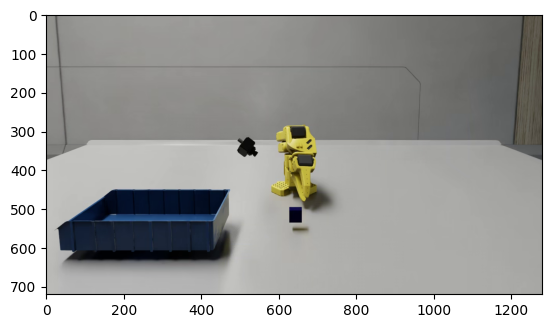

In [22]:
plt.imshow(top_np)

In [23]:
# Convert numpy array to base64
pil_img = Image.fromarray(top_np)
buffer = io.BytesIO()
pil_img.save(buffer, format="PNG")
img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

In [24]:
PROMPT = (
    "Carefully analyze the image and determine if the task 'put the cube in the basket' is already completed.\n"
    "If the cube is already inside the basket, respond with:\n"
    "Task Status: Completed\n"
    "Scene Description: ...\n"
    "Robot State: ...\n"
    "Action Plan: No action needed.\n\n"
    "If the task is not yet finished, provide a full analysis and action plan:\n"
    "Task Status: Not Completed\n"
    "Scene Description: (describe the overall scene)\n"
    "Robot State: (describe the robotic arm's position, orientation, and gripper status)\n"
    "Action Plan: Step 1 ... Step 2 ... Step 3 ... (list steps to pick up the cube and place it in the basket)\n\n"
    "Respond strictly in the format above, with exactly those headings."
)

In [25]:
response = client.chat.completions.create(
    model="Qwen/Qwen2.5-VL-72B-Instruct",
    messages=[{
        "role": "user",
        "content": [
            {"type": "text", "text": PROMPT},
            {"type": "image_url", "image_url": { "url": f"data:image/png;base64,{img_base64}" }
}
        ],
    }],
    max_tokens=300,
)

In [26]:
print("\n" + "=" * 45)
print(f"{'Model Output':^45}")
print("=" * 45)
print(response.choices[0].message.content)
print("=" * 45)


                Model Output                 
Task Status: Not Completed  
Scene Description: The scene shows a yellow robotic arm on a white surface. There is a blue basket on the left side of the robot, which is currently empty. A black cube is located near the robot but outside the basket. Another smaller black object is also present near the robot.  
Robot State: The robotic arm is positioned upright with its grippers open and oriented towards the black cube. It appears ready to grasp the cube.  
Action Plan:  
Step 1: Move the robotic arm closer to the black cube.  
Step 2: Close the grippers to securely grasp the black cube.  
Step 3: Lift the cube off the surface.  
Step 4: Move the arm towards the blue basket.  
Step 5: Release the cube into the basket.  


In [27]:
def process_model_response(response_text):
    """
    Parses the model's response and returns the task status, scene description,
    robot state, and action plan (if any).
    """
    # Initialize default values
    task_status = None
    scene_desc = ""
    robot_state = ""
    action_plan = ""

    # Split response into lines
    
    lines = response_text.strip().split('\n')
    
    current_section = None

    for line in lines:
        line = line.strip()
        if line.startswith("Task Status:"):
            task_status = line.replace("Task Status:", "").strip()
            current_section = "status"
        elif line.startswith("Scene Description:"):
            scene_desc = line.replace("Scene Description:", "").strip()
            current_section = "scene"
        elif line.startswith("Robot State:"):
            robot_state = line.replace("Robot State:", "").strip()
            current_section = "robot"
        elif line.startswith("Action Plan:"):
            action_plan = line.replace("Action Plan:", "").strip()
            current_section = "plan"
        else:
            # Append multiline content to the current section
            if current_section == "scene":
                scene_desc += " " + line
            elif current_section == "robot":
                robot_state += " " + line
            elif current_section == "plan":
                action_plan += " " + line

    return task_status, scene_desc, robot_state, action_plan

In [28]:
content = response.choices[0].message.content.strip()
status, scene, robot, plan = process_model_response(content)

print(f"Task Status: {status}")

if status == "Completed": 
    print("Task already finished. No action needed.")
elif status == "Not Completed": 
    print("Executing action plan...")
    print(f"Plan: {plan}")
else:
    print("Unexpected status. Check response format.")

Task Status: Not Completed
Executing action plan...
Plan:  Step 1: Move the robotic arm closer to the black cube. Step 2: Close the grippers to securely grasp the black cube. Step 3: Lift the cube off the surface. Step 4: Move the arm towards the blue basket. Step 5: Release the cube into the basket.


In [29]:
def process_image_tensor(img_tensor):
    """
    Convert a PyTorch image tensor (CHW format, values in [0,1] or [0,255]) to a numpy array
    in HWC format with dtype uint8.
    """
    # Move to CPU, detach, convert to numpy
    img = img_tensor.detach().cpu()
    # If shape is (C, H, W) with C=3, permute to HWC
    if img.ndim == 3 and img.shape[0] == 3:
        img = img.permute(1, 2, 0)
    img_np = img.numpy()
    # Handle normalization
    if img_np.max() <= 1.0:
        img_np = (img_np * 255).astype(np.uint8)
    else:
        img_np = img_np.astype(np.uint8)
    return img_np

In [30]:
def get_observation(joint_node, image_node) -> dict[str, Any]:
    """
    Read joint state and attach latest image (if available).
    """
    obs_dict = {}
    
    # Read arm joints
    start = time.perf_counter()
    obs_dict["joints"] = ros_to_lerobot(joint_node.get_current_joints())
    dt_ms = (time.perf_counter() - start) * 1e3

    # Attach latest image if available
    if image_node.latest_image is not None:
        obs_dict["image"] = image_node.latest_image

    return obs_dict

In [36]:
rclpy.init()
#Initialize ROS and JointReader
arm_pub = ArmPublisher()
joint_reader = JointReader()
    
# Initialize ROS2 image subscriber
image_node_top = ImageSubscriber(topic_name='/rgb_top')
image_node_left = ImageSubscriber(topic_name='/rgb_left')
executor = rclpy.executors.SingleThreadedExecutor()
executor.add_node(image_node_top)
executor.add_node(image_node_left)

[WARN] [1773615513.933241300] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[WARN] [1773615513.935109626] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.
[WARN] [1773615513.936207472] [rcl.logging_rosout]: Publisher already registered for provided node name. If this is due to multiple nodes with the same name then all logs for that logger name will go 

True

In [41]:
executor.spin_once(timeout_sec=0.1)
executor.spin_once(timeout_sec=0.1)

In [38]:
single_task = "put cube to the baseket"
robot_type = "SO101"

In [49]:
dt = 1.0 / 20.0

prev_action = None
preprocessor.reset()
postprocessor.reset()

frame_counter = 0

for i in range(6000):
    start = time.time()

    executor.spin_once(timeout_sec=0.0)

    obs = ros_to_lerobot(joint_reader.get_current_joints())
    obs['top'] = image_node_top.latest_image
    obs['left'] = image_node_left.latest_image

    obs_processed = robot_observation_processor(obs)
    observation_frame = build_dataset_frame(dataset.features, obs_processed, prefix=OBS_STR)

    action_values = predict_action(
        observation=observation_frame,
        policy=policy,
        device=get_safe_torch_device(cfg.device),
        preprocessor=preprocessor,
        postprocessor=postprocessor,
        use_amp=cfg.use_amp,
        task=single_task,
        robot_type=robot_type,
    )


    action_values = action_values.squeeze(0)

    # --- ACTION SMOOTHING ---
    if prev_action is None:
        prev_action = action_values

    smoothed_action = 0.7 * prev_action + 0.3 * action_values
    prev_action = smoothed_action
    # ------------------------

    action_names = dataset.features[ACTION]["names"]

    act_processed_policy: RobotAction = {
        name: float(smoothed_action[i]) for i, name in enumerate(action_names)
    }

    robot_action_to_send = robot_action_processor((act_processed_policy, obs))
    arm_pub.publish_action(robot_action_to_send)

        # Publish only every 10 frames
    if frame_counter % 10 == 0:
        print("\n" + "=" * 45)
        print("Qwen2.5 action")
        top_np = obs['top']
        pil_img = Image.fromarray(top_np)
        buffer = io.BytesIO()
        pil_img.save(buffer, format="PNG")
        img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
        response = client.chat.completions.create(
            model="Qwen/Qwen2.5-VL-72B-Instruct",
            messages=[{
                "role": "user",
                "content": [ 
                    {"type": "text", "text": PROMPT},
                    {"type": "image_url", "image_url": { "url": f"data:image/png;base64,{img_base64}" }
                    }
                ],
            }],
            max_tokens=300,)
        print(f"{'Model Output':^45}")
        print("=" * 45)
        print(response.choices[0].message.content)
        print("=" * 45)
        single_task = response.choices[0].message.content
        
    frame_counter += 1  # Increment counter


    elapsed = time.time() - start
    if elapsed < dt:
        time.sleep(dt - elapsed)


Qwen2.5 action
                Model Output                 
Task Status: Not Completed  
Scene Description: The scene shows a yellow robotic arm on a white surface. There is a blue basket on the left side of the image, which is currently empty. A black cube is lying on the surface near the center-left, and a smaller blue cube is positioned near the base of the robotic arm. The background is plain gray.  

Robot State: The robotic arm is upright with its grippers open and positioned above the smaller blue cube. It appears ready to grasp an object but has not yet done so.  

Action Plan:  
Step 1: Move the robotic arm downward to grasp the blue cube.  
Step 2: Close the grippers to securely hold the blue cube.  
Step 3: Lift the blue cube off the surface.  
Step 4: Move the robotic arm towards the blue basket.  
Step 5: Release the blue cube into the basket.  

Qwen2.5 action
                Model Output                 
Task Status: Not Completed  
Scene Description: The scene shows a

KeyboardInterrupt: 